In [ ]:
import pandas as pd
import os

data_path = "./Bladder_spatial_data/ftp.ncbi.nlm.nih.gov/geo/samples/GSM9066nnn/GSM9066380/suppl/D1_Johnson/outs/binned_outputs/square_008um"
spatial_path = os.path.join(data_path, "spatial")

# find and convert the parquet file
parquet_file = os.path.join(spatial_path, "tissue_positions.parquet")
csv_file = os.path.join(spatial_path, "tissue_positions_list.csv")

if os.path.exists(parquet_file):
    df = pd.read_parquet(parquet_file)
    df.to_csv(csv_file, index=False)
    print(f"Converted {parquet_file} → {csv_file}")
else:
    print(" No tissue_positions.parquet found — check your path")

/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/squidpy/read/_read.py:82: DtypeWarning: Columns (1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  coords = pd.read_csv(


In [23]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import os
from skimage.io import imread
from skimage.transform import resize
from PIL import Image
import numpy as np

# Path to one of your spatial binning levels
data_path = "./Bladder_spatial_data/ftp.ncbi.nlm.nih.gov/geo/samples/GSM9066nnn/GSM9066380/suppl/D1_Johnson/outs/binned_outputs/square_008um"

# Read in the data
adata = sq.read.visium(path=data_path)

# Inspect the object
print(adata)
print(adata.obs.head())
print(adata.obsm.keys())

Image.MAX_IMAGE_PIXELS = None  # disable decompression bomb check

# Inspect available images and scalefactors
library_id = list(adata.uns['spatial'].keys())[0]
adata.uns['spatial'][library_id]['scalefactors']


/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1794: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/ebouvet/Desktop/Spatial_experimenting/.venv/lib/python3.12/site-packages/squidpy/read/_read.py:82: DtypeWarning: Columns (1,2,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  coords = pd.read_csv(


AnnData object with n_obs × n_vars = 400147 × 18085
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'
                      in_tissue array_row array_col
s_008um_00301_00321-1         1       301       321
s_008um_00602_00290-1         1       602       290
s_008um_00515_00112-1         1       515       112
s_008um_00377_00750-1         1       377       750
s_008um_00789_00234-1         1       789       234
KeysView(AxisArrays with keys: spatial)


{'spot_diameter_fullres': 32.27840390925801,
 'bin_size_um': 8.0,
 'microns_per_pixel': 0.2478437292776258,
 'regist_target_img_scalef': 0.044326242,
 'tissue_lowres_scalef': 0.004432624,
 'fiducial_diameter_fullres': 1331.484161256893,
 'tissue_hires_scalef': 0.044326242}

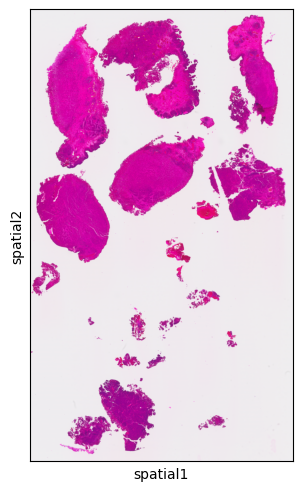

In [25]:

# Convert spatial coordinates to a proper numeric array
adata.obsm["spatial"] = np.array(adata.obsm["spatial"], dtype=float)

adata.obsm["spatial"][:5]
adata.obsm["spatial"].dtype

sq.pl.spatial_scatter(
    adata,
    color=None,
    library_id=list(adata.uns["spatial"].keys())[0],
    size=1.5
)
